# Risk-aware MCTS
#### `four_state_mdp` experiments

In [32]:
import os
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import seaborn as sns
sns.set_style("dark")

matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams.update({'font.size': 16})

sns.set_palette("colorblind")

In [33]:
def calculate_erm(dist, beta):
    dist = np.asarray(dist)
    return (1.0 / beta) * np.log((1 / len(dist)) * np.sum(np.exp(beta * dist)))

In [34]:
def erm_ci(samples: np.ndarray, beta: float, num_resamples: int = 25_000):
    # Confidence interval estimation via bootstrap resampling.
    samples = np.asarray(samples)
    resampled = np.random.choice(samples, size=(len(samples), num_resamples), replace=True).T
    erms = (1.0 / beta) * np.log((1 / resampled.shape[1]) * np.sum(np.exp(beta * resampled), axis=1))
    return [np.percentile(erms, 5), np.percentile(erms, 95)]

### Load experiment data

Reads every completed cell for this environment from the sweep's `manifest.json` / `exp_data.json` files (output of `run_experiments.py`).

In [35]:
SWEEP_DIR = 'data/sweep_demo_2026-09-23-18-28-13_seed0'
ENV_NAME = 'four_state_mdp'

with open(os.path.join(SWEEP_DIR, "manifest.json")) as f:
    manifest = json.load(f)

# algo -> beta -> n_iter -> f_vals   (n_iter is None for erm-bi, which doesn't use it)
data = {}
for cell_name, meta in manifest["cells"].items():
    if meta["env"] != ENV_NAME or meta["status"] != "done":
        continue
    exp_path = os.path.join(SWEEP_DIR, cell_name, "exp_data.json")
    with open(exp_path) as f:
        raw = json.load(f)
    exp = json.loads(raw) if isinstance(raw, str) else raw

    algo = meta["algo"]
    beta = meta["erm_beta"]
    n_iter = meta["n_iter"]  # None for erm-bi
    data.setdefault(algo, {}).setdefault(beta, {})[n_iter] = exp["f_vals"]

algos = sorted(data.keys())
betas = sorted({b for algo_d in data.values() for b in algo_d.keys()})
n_iters = sorted({n for algo_d in data.values() for beta_d in algo_d.values() for n in beta_d.keys() if n is not None})
n_iter_to_plot = n_iters[-1] if n_iters else None  # n_iter slice used by the plots below

print("algos:", algos)
print("betas:", betas)
print("n_iters:", n_iters)
print("n_iter_to_plot:", n_iter_to_plot)

algos: ['acc-mcts', 'erm-bi', 'erm-mcts']
betas: [0.01, 0.1, 1.0, 5.0, 10]
n_iters: [100, 500, 1000, 2000]
n_iter_to_plot: 2000


### ERM vs. planning budget (`n_iter`), for a fixed `beta`

Compares the sampling-based planners (`erm-mcts`, `acc-mcts`) as the per-timestep iteration budget grows. `erm-bi`, the exact oracle, doesn't depend on `n_iter` and is drawn as a flat reference line when available.

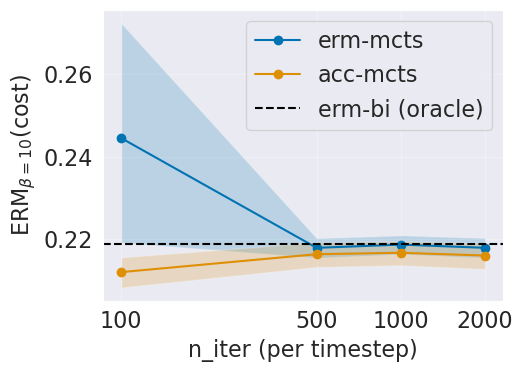

In [36]:
erm_beta_to_plot = betas[-1]

fig, ax = plt.subplots(figsize=(5.5, 4.0))

for algo, algo_d in data.items():
    if erm_beta_to_plot not in algo_d:
        continue
    beta_d = algo_d[erm_beta_to_plot]

    if algo == "erm-bi":
        # Oracle: no n_iter dependence, draw as a horizontal reference line.
        f_vals = beta_d[None]
        erm_val = calculate_erm(f_vals, beta=erm_beta_to_plot)
        ax.axhline(erm_val, linestyle="--", color="black", label="erm-bi (oracle)")
        continue

    xs = sorted(n for n in beta_d.keys() if n is not None)
    ys = [calculate_erm(beta_d[n], beta=erm_beta_to_plot) for n in xs]
    cis = [erm_ci(beta_d[n], beta=erm_beta_to_plot) for n in xs]
    lower = [y - ci[0] for y, ci in zip(ys, cis)]
    upper = [ci[1] - y for y, ci in zip(ys, cis)]

    ax.plot(xs, ys, marker="o", label=algo)
    ax.fill_between(xs, np.array(ys) - lower, np.array(ys) + upper, alpha=0.2)

ax.set_xlabel("n_iter (per timestep)")
ax.set_ylabel(fr"ERM$_{{\beta={erm_beta_to_plot}}}$(cost)")
ax.set_xscale("log")
ax.set_xticks(n_iters)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

### Distribution of costs, per algorithm

Histogram of the (discounted) cumulative cost `f_vals` across episodes, one panel per algorithm, overlaying all `beta` values at the fixed `n_iter` chosen above.

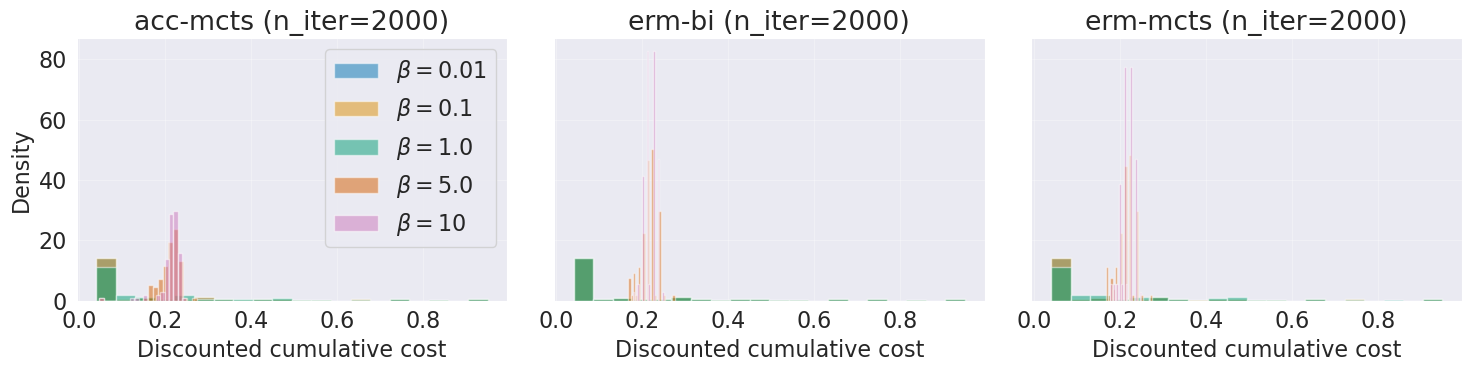

In [37]:
fig, axes = plt.subplots(1, len(algos), figsize=(5.0 * len(algos), 4.0), sharey=True)
if len(algos) == 1:
    axes = [axes]

for ax, algo in zip(axes, algos):
    algo_d = data[algo]
    for beta in betas:
        if beta not in algo_d:
            continue
        key = None if algo == "erm-bi" else n_iter_to_plot
        if key not in algo_d[beta]:
            continue
        ax.hist(algo_d[beta][key], density=True, bins=20, alpha=0.5, label=fr"$\beta={beta}$")
    ax.set_title(f"{algo} (n_iter={n_iter_to_plot})")
    ax.set_xlabel("Discounted cumulative cost")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Density")
axes[0].legend()
fig.tight_layout()
plt.show()

### Boxplot comparison across algorithms and betas (fixed `n_iter`)

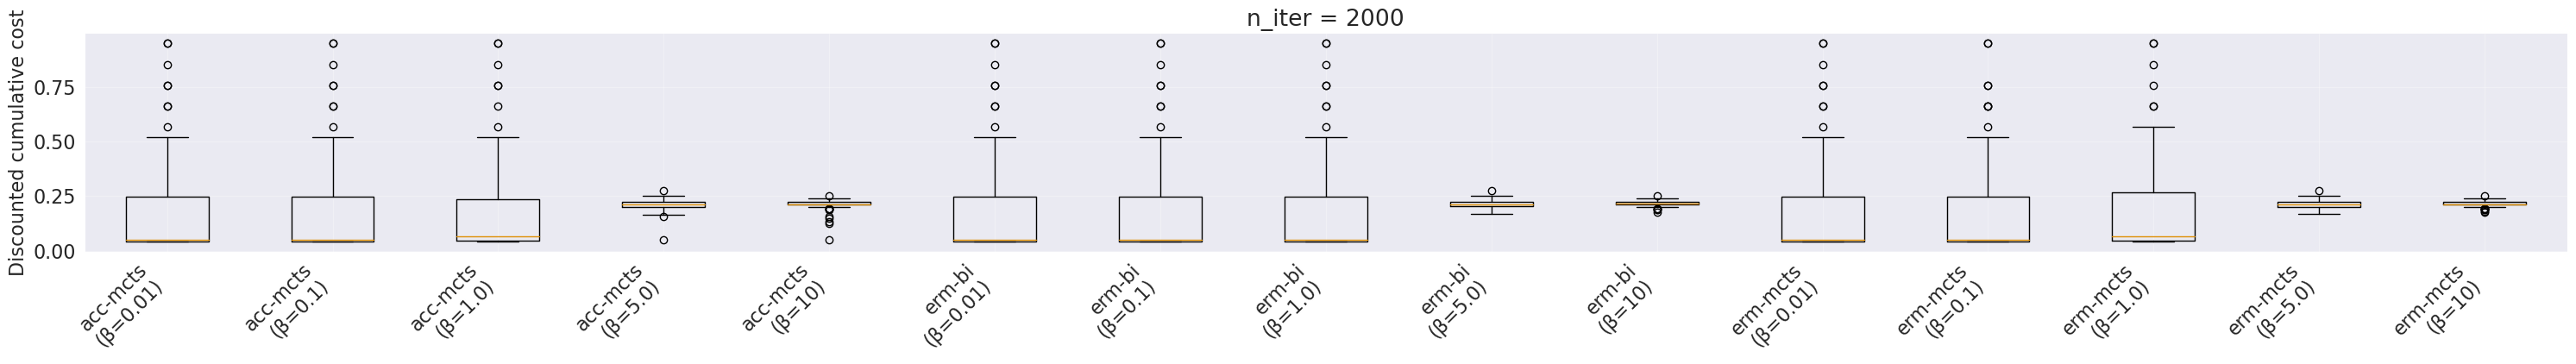

In [38]:
fig, ax = plt.subplots(figsize=(2.0 * len(algos) * len(betas), 4.5))

data_to_plot, labels = [], []
for algo in algos:
    algo_d = data[algo]
    for beta in betas:
        if beta not in algo_d:
            continue
        key = None if algo == "erm-bi" else n_iter_to_plot
        if key not in algo_d[beta]:
            continue
        data_to_plot.append(algo_d[beta][key])
        labels.append(f"{algo}\n(β={beta})")

ax.boxplot(data_to_plot, labels=labels)
ax.set_title(f"n_iter = {n_iter_to_plot}")
ax.set_ylabel("Discounted cumulative cost")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()